# WESAD Stress Prediction: LOSO Cross-Validation

This notebook implements a machine learning pipeline for stress detection using the WESAD dataset, focusing on wrist-worn sensor data. The primary goal is to build and evaluate several models using a rigorous Leave-One-Subject-Out (LOSO) cross-validation strategy, as required for subject-independent evaluation.

The analysis is divided into two distinct tasks, consistent with the original WESAD paper (Schmidt et al., 2018):
1.  **Multi-Class Classification**: A 4-class problem to distinguish between Baseline (1), Stress (2), Amusement (3), and Meditation (4).
2.  **Binary Classification**: A 2-class problem to detect Stress (1) vs. Non-Stress (0), where Non-Stress combines the Baseline, Amusement, and Meditation states.

The models evaluated are Logistic Regression, Support Vector Machine (SVM), XGBoost, and a Multi-Layer Perceptron (MLP). We also include a Random Forest classifier as a reference, as it was a top-performing model in the original paper's benchmark.

In [3]:
import os
import json
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.calibration import calibration_curve
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', None)

print('Imports loaded')

Imports loaded


## 2. Load and Prepare Feature Matrix

In [6]:
### 2.1 Load CSV
DATA_PATH = Path('wesad_wrist_features.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Missing file: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH)
print('Original shape:', df.shape)
display(df.head())

print("\nColumns and Dtypes:")
print(df.info())

Original shape: (179817, 46)


,subject,window_index,label,bvp_hr_mean,bvp_hr_std,bvp_hrv_mean,bvp_hrv_std,bvp_hrv_nn50,bvp_hrv_pnn50,bvp_hrv_rmssd,bvp_hrv_ulf,bvp_hrv_lf,bvp_hrv_hf,bvp_hrv_uhf,bvp_hrv_lf_hf,eda_mean,eda_std,eda_min,eda_max,eda_slope,eda_range,eda_scr_peaks,eda_scr_mean_amp,eda_scr_auc,temp_mean,temp_std,temp_min,temp_max,temp_range,temp_slope,acc_x_mean,acc_x_std,acc_y_mean,acc_y_std,acc_z_mean,acc_z_std,acc_mag_mean,acc_mag_std,acc_x_absint,acc_y_absint,acc_z_absint,acc_x_peakfreq,acc_y_peakfreq,acc_z_peakfreq,eda_scr_has_peaks,bvp_hrv_freq_valid
0,S10,0,1,92.222633,30.733178,729.552469,259.659106,60,0.750000,391.919729,0.001551,0.005276,0.025225,0.009141,0.209149,0.388696,0.044754,0.34759,0.606228,0.001623,0.258638,7,0.062677,0.415006,33.247683,0.048199,33.176,33.322,0.146,0.002654,39.746387,12.666104,2.475993,3.129106,41.014355,19.997278,61.879907,3.012126,2384.783203,202.807617,2570.923828,0.125,0.125,0.125,1,1
1,S10,1,1,92.222633,30.733178,729.552469,259.659106,60,0.750000,391.919729,0.001551,0.005276,0.025225,0.009141,0.209149,0.388972,0.044758,0.34759,0.606228,0.001624,0.258638,7,0.062677,0.414869,33.248181,0.048316,33.176,33.322,0.146,0.002663,39.630241,12.626917,2.457064,3.110095,41.140055,19.991351,61.877399,3.008428,2377.814453,201.671875,2578.465820,0.125,0.125,0.125,1,1
2,S10,2,1,92.743837,30.566826,723.828125,256.147262,59,0.746835,389.281709,0.001605,0.005238,0.025854,0.009290,0.202613,0.389237,0.044763,0.34759,0.606228,0.001624,0.258638,7,0.062677,0.414794,33.248677,0.048440,33.176,33.322,0.146,0.002673,39.513574,12.586034,2.439437,3.092266,41.265267,19.984413,61.873905,3.010429,2370.814453,200.614258,2585.978516,0.125,0.125,0.125,1,1
3,S10,3,1,92.652350,30.388575,723.572531,254.571460,59,0.737500,386.844992,0.001604,0.005119,0.025099,0.009718,0.203935,0.389497,0.044764,0.34759,0.606228,0.001625,0.258638,7,0.062677,0.414637,33.249171,0.048570,33.176,33.322,0.146,0.002684,39.397217,12.544515,2.423535,3.075650,41.390365,19.976378,61.870738,3.011397,2363.833008,199.660156,2593.484375,0.125,0.125,0.125,1,1
4,S10,4,1,92.629447,30.394781,723.765432,254.561813,59,0.737500,386.856825,0.001603,0.005119,0.025099,0.009718,0.203940,0.389762,0.044763,0.34759,0.606228,0.001625,0.258638,7,0.062677,0.414685,33.249662,0.048708,33.176,33.322,0.146,0.002695,39.281429,12.502663,2.409635,3.060331,41.516048,19.967527,61.868780,3.009604,2356.885742,198.826172,2601.025391,0.125,0.125,0.125,1,1



Columns and Dtypes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179817 entries, 0 to 179816
Data columns (total 46 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   subject             179817 non-null  object 
 1   window_index        179817 non-null  int64  
 2   label               179817 non-null  int64  
 3   bvp_hr_mean         179817 non-null  float64
 4   bvp_hr_std          179817 non-null  float64
 5   bvp_hrv_mean        179817 non-null  float64
 6   bvp_hrv_std         179817 non-null  float64
 7   bvp_hrv_nn50        179817 non-null  int64  
 8   bvp_hrv_pnn50       179817 non-null  float64
 9   bvp_hrv_rmssd       179817 non-null  float64
 10  bvp_hrv_ulf         179817 non-null  float64
 11  bvp_hrv_lf          179817 non-null  float64
 12  bvp_hrv_hf          179817 non-null  float64
 13  bvp_hrv_uhf         179817 non-null  float64
 14  bvp_hrv_lf_hf       179817 non-null  float64
 15  eda_mean     

In [9]:
### 2.2 Inspect Data Quality

# Null percentage
null_pct = df.isnull().mean() * 100
print("Null values percentage per column (>0%):")
print(null_pct[null_pct > 0].sort_values(ascending=False))
if null_pct.max() == 0:
    print("No null values found.")

# Zero percentage
zero_pct = (df == 0).mean() * 100
print("\nZero values percentage per column (>1%):")
print(zero_pct[zero_pct > 1].sort_values(ascending=False))

# Boolean-like columns (numeric only)
numeric_cols = df.select_dtypes(include=np.number).columns
bool_cols = [col for col in numeric_cols
             if df[col].nunique() <= 2
             and df[col].min() == 0
             and df[col].max() == 1]

# Also catch constant columns (only one unique value — zero information)
constant_cols = [col for col in numeric_cols
                 if df[col].nunique() == 1]

print(f"Boolean-like columns found: {bool_cols}")
print(f"Constant columns found (zero information): {constant_cols}")

Null values percentage per column (>0%):
Series([], dtype: float64)
No null values found.

Zero values percentage per column (>1%):
eda_scr_mean_amp    16.53292
dtype: float64
Boolean-like columns found: ['bvp_hrv_freq_valid']
Constant columns found (zero information): ['eda_scr_has_peaks']


In [10]:
### 2.3 Clean the Feature Matrix

# Drop flag and constant columns — these are metadata about feature extraction
# quality, not physiological features:
# - bvp_hrv_freq_valid: validity flag for HRV frequency analysis
# - eda_scr_has_peaks: constant (always 1), carries zero information
flag_keywords = ['valid', 'has_']
flag_cols = [c for c in df.columns if any(kw in c.lower() for kw in flag_keywords)]
df = df.drop(columns=flag_cols)
print(f"Dropped {len(flag_cols)} flag/constant columns: {flag_cols}")

# No null imputation needed — confirmed no nulls in Section 2.2
# No further dropping needed — no columns exceeded 50% null threshold
print(f"Nulls remaining: {df.isnull().sum().sum()}")
print(f"Final shape after cleaning: {df.shape}")

Dropped 2 flag/constant columns: ['eda_scr_has_peaks', 'bvp_hrv_freq_valid']
Nulls remaining: 0
Final shape after cleaning: (179817, 44)


Final shape: (179817, 44)
Final number of features: 41

Label distribution per subject:


label,Baseline,Stress,Amusement,Meditation
subject,,,,
S10,4720,2900,1488,3184
S11,4720,2720,1472,3164
S13,4720,2656,1528,3180
S14,4705,2700,1488,3176
S15,4700,2744,1488,3176
S16,4720,2692,1472,3168
S17,4724,2892,1488,2924
S2,4576,2460,1448,3072
S3,4560,2560,1500,3120


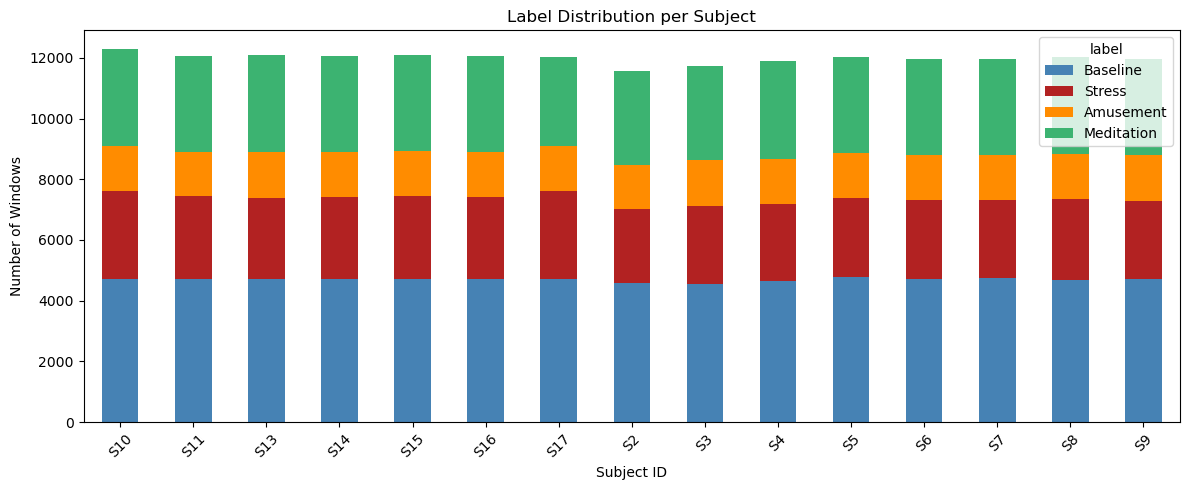

In [11]:
### 2.4 Verify and Summarize

print("Final shape:", df.shape)
final_feature_cols = df.select_dtypes(include=np.number).columns.drop(
    ['label', 'window_index'], errors='ignore').tolist()
print(f"Final number of features: {len(final_feature_cols)}")

# Label distribution per subject
label_dist = df.groupby('subject')['label'].value_counts().unstack(fill_value=0)
label_dist = label_dist.rename(columns={
    1: 'Baseline',
    2: 'Stress',
    3: 'Amusement',
    4: 'Meditation'
})
print("\nLabel distribution per subject:")
display(label_dist)

# Plot label distribution
label_dist.plot(kind='bar', stacked=True, figsize=(12, 5),
                color=['steelblue', 'firebrick', 'darkorange', 'mediumseagreen'])
plt.ylabel('Number of Windows')
plt.xlabel('Subject ID')
plt.title('Label Distribution per Subject')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
### 2.5 Define Classification Tasks

# Feature matrix and group labels (same for both tasks)
X = df.drop(columns=['subject', 'label', 'window_index'])
groups = df['subject']

# Multi-class task: 1=Baseline, 2=Stress, 3=Amusement, 4=Meditation
y_multi = df['label'].astype(int)

# Binary task: stress (label=2) → 1, everything else → 0
# Consistent with Schmidt et al. (2018) binary task definition
y_binary = df['label'].apply(lambda x: 1 if x == 2 else 0)

print("--- Multi-class Task ---")
print("Labels: 1=Baseline, 2=Stress, 3=Amusement, 4=Meditation")
print("Class distribution:\n", y_multi.value_counts().sort_index())

print("\n--- Binary Task ---")
print("Labels: 1=Stress, 0=Non-Stress")
print("Class distribution:\n", y_binary.value_counts().sort_index())

--- Multi-class Task ---
Labels: 1=Baseline, 2=Stress, 3=Amusement, 4=Meditation
Class distribution:
 label
1    70429
2    39864
3    22300
4    47224
Name: count, dtype: int64

--- Binary Task ---
Labels: 1=Stress, 0=Non-Stress
Class distribution:
 label
0    139953
1     39864
Name: count, dtype: int64


## 3. Feature Analysis
Understanding feature distributions and correlations helps interpret model results and identify potential issues like multicollinearity before modelling.

Found 8 pairs with correlation > 0.95
  feature_1     feature_2  correlation
bvp_hrv_std bvp_hrv_rmssd     0.986541
   eda_mean       eda_min     0.997976
   eda_mean       eda_max     0.997819
    eda_std     eda_range     0.965683
    eda_min       eda_max     0.993250
  temp_mean      temp_min     0.998387
  temp_mean      temp_max     0.999475
   temp_min      temp_max     0.996937


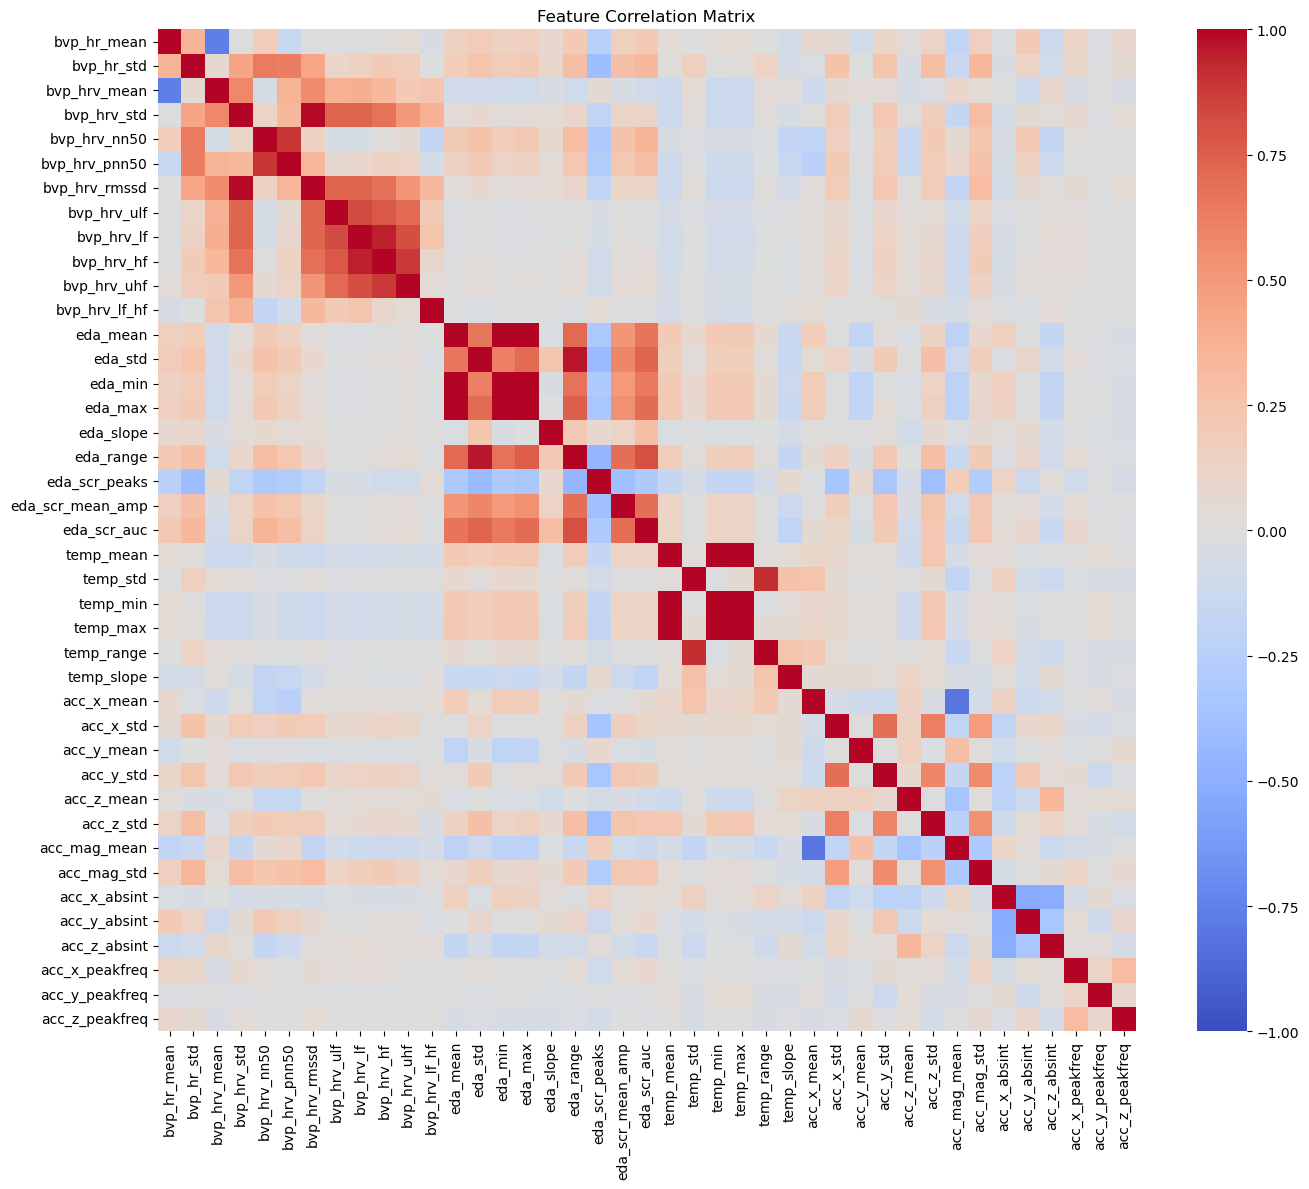

In [ ]:
### 3.1 Feature Correlation Heatmap
corr_matrix = X[final_feature_cols].corr()

# Find highly correlated pairs
highly_corr_pairs = (
    corr_matrix.abs()
    .stack()
    .reset_index()
    .rename(columns={0: 'correlation', 'level_0': 'feature_1', 'level_1': 'feature_2'})
)
highly_corr_pairs = highly_corr_pairs[
    (highly_corr_pairs['feature_1'] != highly_corr_pairs['feature_2']) &
    (highly_corr_pairs['correlation'] > 0.95)
]
highly_corr_pairs['pair'] = highly_corr_pairs.apply(
    lambda row: tuple(sorted((row['feature_1'], row['feature_2']))), axis=1)
highly_corr_pairs = highly_corr_pairs.drop_duplicates(subset='pair')

print(f"Found {len(highly_corr_pairs)} pairs with correlation > 0.95")
print(highly_corr_pairs[['feature_1', 'feature_2', 'correlation']].to_string(index=False))

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

Plotting 6 representative features: ['bvp_hr_mean', 'eda_mean', 'temp_mean', 'acc_mag_mean', 'eda_scr_peaks', 'bvp_hrv_rmssd']


C:\Users\vikku\AppData\Local\Temp\ipykernel_47324\4086431495.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([label_names[l] for l in sorted(y_multi.unique())],
C:\Users\vikku\AppData\Local\Temp\ipykernel_47324\4086431495.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([label_names[l] for l in sorted(y_multi.unique())],
C:\Users\vikku\AppData\Local\Temp\ipykernel_47324\4086431495.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([label_names[l] for l in sorted(y_multi.unique())],
C:\Users\vikku\AppData\Local\Temp\ipykernel_47324\4086431495.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or usin

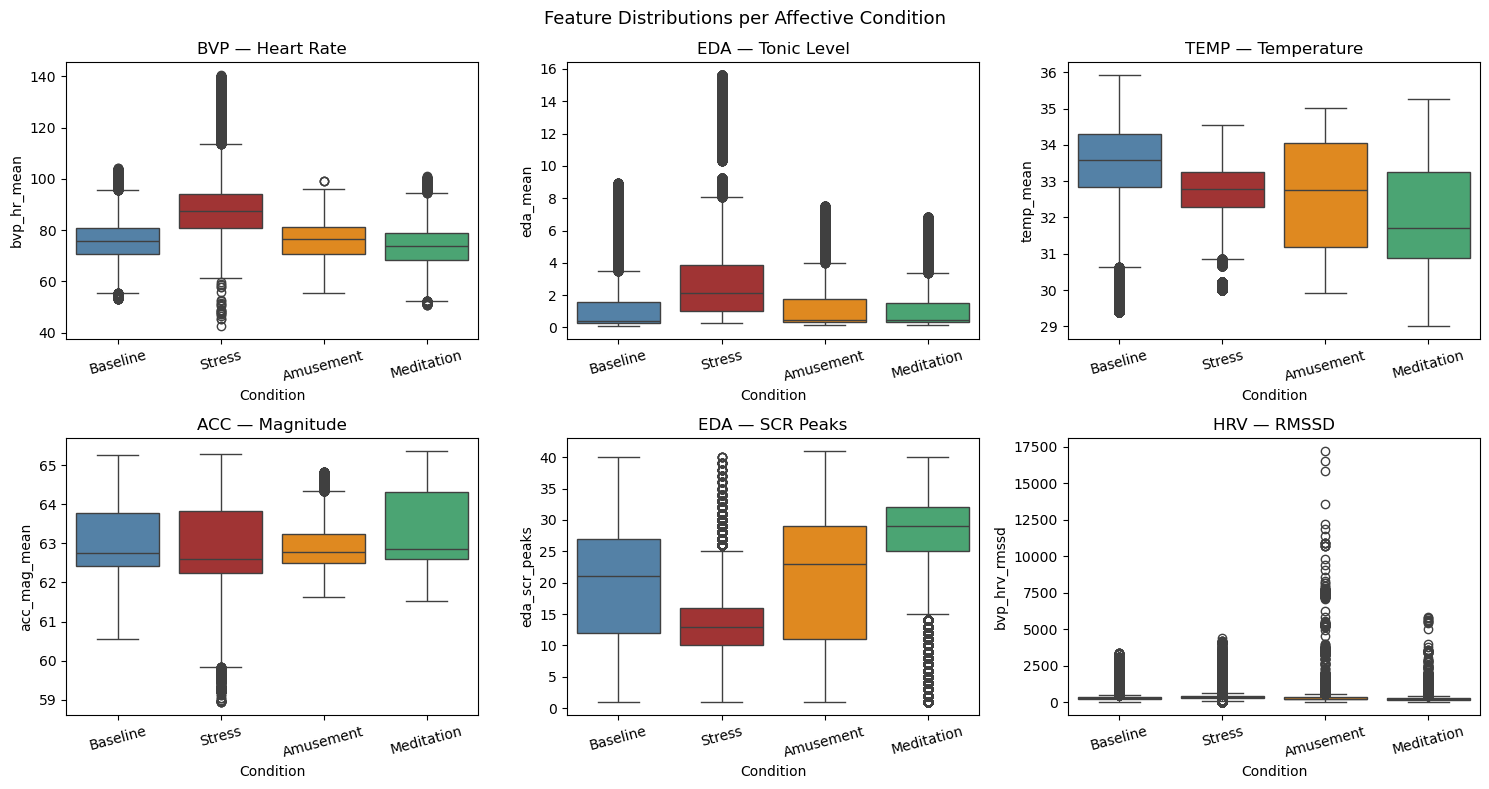

In [15]:
### 3.2 Feature Distributions per Class

# Representative features per signal type — using actual column names from our CSV
rep_features = {
    'BVP — Heart Rate': 'bvp_hr_mean',
    'EDA — Tonic Level': 'eda_mean',
    'TEMP — Temperature': 'temp_mean',
    'ACC — Magnitude': 'acc_mag_mean',
    'EDA — SCR Peaks': 'eda_scr_peaks',
    'HRV — RMSSD': 'bvp_hrv_rmssd',
}

# Only plot features that actually exist in X
valid_rep_features = {k: v for k, v in rep_features.items() if v in X.columns}
print(f"Plotting {len(valid_rep_features)} representative features: {list(valid_rep_features.values())}")

label_names = {1: 'Baseline', 2: 'Stress', 3: 'Amusement', 4: 'Meditation'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (signal, feature) in enumerate(valid_rep_features.items()):
    sns.boxplot(x=y_multi, y=X[feature], ax=axes[i],
                palette=['steelblue', 'firebrick', 'darkorange', 'mediumseagreen'])
    axes[i].set_title(f'{signal}')
    axes[i].set_xlabel('Condition')
    axes[i].set_xticklabels([label_names[l] for l in sorted(y_multi.unique())],
                             rotation=15)

plt.suptitle('Feature Distributions per Affective Condition', fontsize=13)
plt.tight_layout()
plt.show()

Top 15 most variable features across subjects:
acc_z_absint     392.305630
acc_y_absint     376.159104
acc_x_absint     287.727757
bvp_hrv_rmssd     89.373994
bvp_hrv_std       66.804950
bvp_hrv_mean      61.322149
acc_x_mean        43.739119
acc_z_mean        12.602790
acc_y_mean         8.677958
bvp_hrv_nn50       5.368181
bvp_hr_mean        5.017723
eda_scr_peaks      3.760759
bvp_hr_std         3.122841
acc_z_std          2.212400
eda_max            2.087211


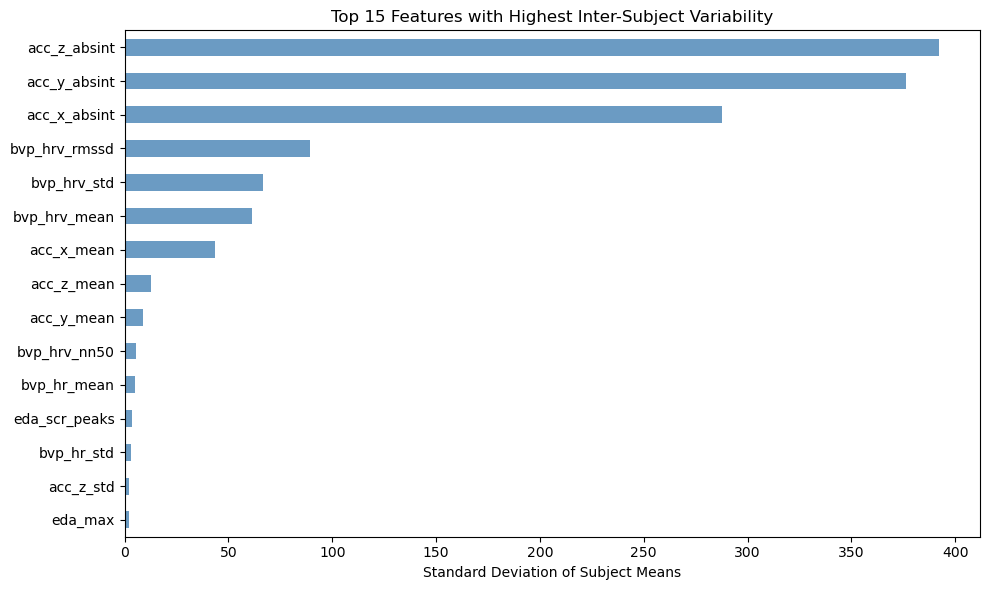

In [16]:
### 3.3 Inter-Subject Variability

# Compute std of feature means across subjects
# High std means the feature varies a lot between subjects — 
# motivating subject-level normalization inside the LOSO loop
subject_means = df.groupby('subject')[final_feature_cols].mean()
inter_subject_std = subject_means.std().sort_values(ascending=False)

print("Top 15 most variable features across subjects:")
print(inter_subject_std.head(15).to_string())

plt.figure(figsize=(10, 6))
inter_subject_std.head(15).plot(kind='barh', color='steelblue', alpha=0.8)
plt.title('Top 15 Features with Highest Inter-Subject Variability')
plt.xlabel('Standard Deviation of Subject Means')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Feature Selection

We use cluster forward selection to avoid collapsing to a single feature when many features are highly correlated. First, we cluster features based on absolute correlation. Then we pick one representative per cluster (highest variance) and run a greedy forward selection using LOSO macro F1 to select up to 20 features.

*Note on Data Leakage*: Feature selection is performed on the full dataset for simplicity and a stable feature set. Strictly, it should be done inside the LOSO loop on training data only. This is a limitation.

In [17]:
# Cluster features with |corr| >= 0.90 to avoid keeping redundant features
corr_threshold = 0.90
corr_abs = X[final_feature_cols].corr().abs().fillna(0)

distance_values = (1 - corr_abs).to_numpy().copy()
np.fill_diagonal(distance_values, 0)

condensed = squareform(distance_values, checks=False)
linkage_matrix = linkage(condensed, method='average')
cluster_labels = fcluster(linkage_matrix, t=1 - corr_threshold, criterion='distance')

clusters = {}
for feature, cluster_id in zip(final_feature_cols, cluster_labels):
    clusters.setdefault(cluster_id, []).append(feature)

print(f"Formed {len(clusters)} clusters at |corr| >= {corr_threshold}")
for cid, feats in sorted(clusters.items()):
    print(f"  Cluster {cid}: {feats}")

Formed 33 clusters at |corr| >= 0.9
  Cluster 1: ['acc_x_peakfreq']
  Cluster 2: ['acc_z_peakfreq']
  Cluster 3: ['acc_y_peakfreq']
  Cluster 4: ['bvp_hr_mean']
  Cluster 5: ['bvp_hrv_mean']
  Cluster 6: ['bvp_hrv_std', 'bvp_hrv_rmssd']
  Cluster 7: ['bvp_hrv_lf', 'bvp_hrv_hf']
  Cluster 8: ['bvp_hrv_uhf']
  Cluster 9: ['bvp_hrv_ulf']
  Cluster 10: ['bvp_hrv_lf_hf']
  Cluster 11: ['temp_mean', 'temp_min', 'temp_max']
  Cluster 12: ['acc_x_std']
  Cluster 13: ['acc_y_std']
  Cluster 14: ['acc_z_std']
  Cluster 15: ['acc_mag_std']
  Cluster 16: ['bvp_hrv_nn50']
  Cluster 17: ['bvp_hrv_pnn50']
  Cluster 18: ['bvp_hr_std']
  Cluster 19: ['eda_mean', 'eda_min', 'eda_max']
  Cluster 20: ['eda_std', 'eda_range']
  Cluster 21: ['eda_scr_auc']
  Cluster 22: ['eda_scr_mean_amp']
  Cluster 23: ['eda_scr_peaks']
  Cluster 24: ['temp_std', 'temp_range']
  Cluster 25: ['temp_slope']
  Cluster 26: ['acc_x_absint']
  Cluster 27: ['acc_y_absint']
  Cluster 28: ['acc_z_absint']
  Cluster 29: ['acc_x_mea

In [18]:
# Pick the highest-variance feature from each cluster as representative
rep_features = []
for cluster_id, feats in clusters.items():
    variances = X[feats].var().sort_values(ascending=False)
    rep_features.append(variances.index[0])

print(f"Selected {len(rep_features)} cluster representatives:")
print(rep_features)

Selected 33 cluster representatives:
['bvp_hr_mean', 'bvp_hr_std', 'bvp_hrv_mean', 'bvp_hrv_rmssd', 'bvp_hrv_nn50', 'bvp_hrv_pnn50', 'bvp_hrv_ulf', 'bvp_hrv_lf', 'bvp_hrv_uhf', 'bvp_hrv_lf_hf', 'eda_max', 'eda_range', 'eda_slope', 'eda_scr_peaks', 'eda_scr_mean_amp', 'eda_scr_auc', 'temp_max', 'temp_range', 'temp_slope', 'acc_x_mean', 'acc_x_std', 'acc_y_mean', 'acc_y_std', 'acc_z_mean', 'acc_z_std', 'acc_mag_mean', 'acc_mag_std', 'acc_x_absint', 'acc_y_absint', 'acc_z_absint', 'acc_x_peakfreq', 'acc_y_peakfreq', 'acc_z_peakfreq']


Feature importances (all cluster representatives):
acc_y_std           0.172010
eda_scr_auc         0.152665
acc_z_std           0.113110
acc_y_peakfreq      0.043987
acc_x_mean          0.034490
bvp_hr_mean         0.033999
eda_max             0.033311
temp_max            0.032110
acc_x_std           0.028574
acc_x_absint        0.025450
bvp_hrv_nn50        0.025200
acc_z_mean          0.024853
temp_range          0.024252
acc_z_absint        0.023019
acc_mag_mean        0.022511
bvp_hrv_rmssd       0.021735
acc_y_mean          0.020340
acc_y_absint        0.018270
temp_slope          0.018128
eda_slope           0.017905
eda_scr_peaks       0.016634
bvp_hrv_mean        0.016206
eda_range           0.015268
bvp_hrv_uhf         0.012792
bvp_hrv_lf          0.011412
bvp_hrv_pnn50       0.009297
acc_mag_std         0.008287
bvp_hrv_lf_hf       0.007313
eda_scr_mean_amp    0.006879
bvp_hr_std          0.006517
bvp_hrv_ulf         0.002773
acc_x_peakfreq      0.000703
acc_z_peakfreq      0

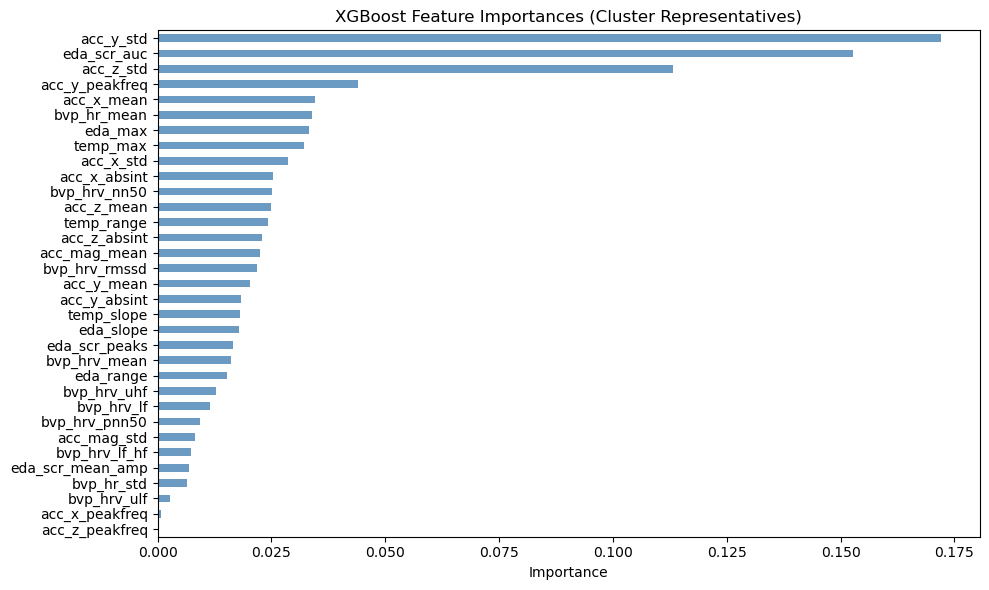

In [19]:
# Fit XGBoost on full dataset using cluster representatives
# Labels shifted to 0-indexed as required by XGBoost
xgb_selector = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    eval_metric='mlogloss', random_state=42
)
xgb_selector.fit(X[rep_features], y_multi - 1)

importances = pd.Series(
    xgb_selector.feature_importances_,
    index=rep_features
).sort_values(ascending=False)

print("Feature importances (all cluster representatives):")
print(importances.to_string())

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue', alpha=0.8)
plt.title('XGBoost Feature Importances (Cluster Representatives)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
# Select top 20 features by XGBoost importance
top_n = min(20, len(rep_features))
final_selected_features = importances.head(top_n).index.tolist()

print(f"Final selected features (top {top_n}):")
for i, f in enumerate(final_selected_features, 1):
    print(f"  {i:2d}. {f}  (importance={importances[f]:.4f})")

X_selected = X[final_selected_features].copy()
print(f"\nFinal feature matrix shape: {X_selected.shape}")

Final selected features (top 20):
   1. acc_y_std  (importance=0.1720)
   2. eda_scr_auc  (importance=0.1527)
   3. acc_z_std  (importance=0.1131)
   4. acc_y_peakfreq  (importance=0.0440)
   5. acc_x_mean  (importance=0.0345)
   6. bvp_hr_mean  (importance=0.0340)
   7. eda_max  (importance=0.0333)
   8. temp_max  (importance=0.0321)
   9. acc_x_std  (importance=0.0286)
  10. acc_x_absint  (importance=0.0255)
  11. bvp_hrv_nn50  (importance=0.0252)
  12. acc_z_mean  (importance=0.0249)
  13. temp_range  (importance=0.0243)
  14. acc_z_absint  (importance=0.0230)
  15. acc_mag_mean  (importance=0.0225)
  16. bvp_hrv_rmssd  (importance=0.0217)
  17. acc_y_mean  (importance=0.0203)
  18. acc_y_absint  (importance=0.0183)
  19. temp_slope  (importance=0.0181)
  20. eda_slope  (importance=0.0179)

Final feature matrix shape: (179817, 20)


In [26]:
### 4.1 Cluster Features by Correlation

# Cluster highly correlated features to avoid collapsing to a single feature
corr_threshold = 0.9  # cluster features with |corr| >= 0.9
corr_abs = X[final_feature_cols].corr().abs().fillna(0)

# Convert to distance (1 - correlation)
distance = (1 - corr_abs).copy()
distance_values = distance.to_numpy().copy()
np.fill_diagonal(distance_values, 0)

# Hierarchical clustering on the distance matrix
condensed = squareform(distance_values, checks=False)
linkage_matrix = linkage(condensed, method='average')
cluster_labels = fcluster(linkage_matrix, t=1 - corr_threshold, criterion='distance')

clusters = {}
for feature, cluster_id in zip(final_feature_cols, cluster_labels):
    clusters.setdefault(cluster_id, []).append(feature)

print(f"Formed {len(clusters)} feature clusters at |corr| >= {corr_threshold}.")

Formed 33 feature clusters at |corr| >= 0.9.


In [ ]:
### 4.2 Cluster Forward Selection (Representative + Greedy)

# Step 1: pick one representative per cluster (highest variance)
rep_features = []
for cluster_id, feats in clusters.items():
    variances = X[feats].var().sort_values(ascending=False)
    rep_features.append(variances.index[0])

print(f"Selected {len(rep_features)} cluster representatives.")

# Step 2: forward selection over representatives using LOSO + Logistic Regression

def eval_feature_set(feature_list, X_all, y, groups):
    if len(feature_list) == 0:
        return 0.0

    X_sub = X_all[feature_list]
    logo = LeaveOneGroupOut()
    scores = []

    for train_idx, test_idx in logo.split(X_sub, y, groups):
        X_train, X_test = X_sub.iloc[train_idx], X_sub.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        scores.append(f1_score(y_test, y_pred, average='macro', zero_division=0))

    return float(np.mean(scores))

max_features = min(20, len(rep_features))
selected = []
remaining = rep_features.copy()

print("Starting forward selection...")
for step in range(max_features):
    best_feat = None
    best_score = -1

    for feat in remaining:
        score = eval_feature_set(selected + [feat], X, y_multi, groups)
        if score > best_score:
            best_score = score
            best_feat = feat

    if best_feat is None:
        break

    selected.append(best_feat)
    remaining.remove(best_feat)
    print(f"Step {step+1:02d}: added {best_feat} (LOSO F1={best_score:.4f})")

final_selected_features = selected
print(f"Final selected features ({len(final_selected_features)}):")
print(final_selected_features)

Selected 33 cluster representatives.
Starting forward selection...
Step 01: added bvp_hr_std (LOSO F1=0.3771)
Step 02: added acc_z_std (LOSO F1=0.4629)
Step 03: added bvp_hr_mean (LOSO F1=0.4977)
Step 04: added bvp_hrv_pnn50 (LOSO F1=0.5320)
Step 05: added eda_scr_auc (LOSO F1=0.5411)
Step 06: added acc_y_peakfreq (LOSO F1=0.5519)
Step 07: added bvp_hrv_nn50 (LOSO F1=0.5619)
Step 08: added eda_scr_peaks (LOSO F1=0.5695)
Step 09: added eda_scr_mean_amp (LOSO F1=0.5746)


In [ ]:
### 4.3 Set Final Feature Matrix

X_selected = X[final_selected_features].copy()
print("Final selected feature matrix shape:", X_selected.shape)

Final selected features for modeling:
['acc_mag_mean']


## 5. LOSO Cross-Validation Framework

### Leave-One-Subject-Out (LOSO) Explained

Random splits are not valid for WESAD because samples from the same subject are highly correlated. A random split can place data from the same person in both training and test sets, inflating performance. LOSO removes this leakage by holding out one subject entirely for testing and training on the remaining subjects. With 15 subjects, this yields 15 folds. This strategy matches the evaluation protocol in Schmidt et al. (2018), Section 4.3.

### Model Hyperparameters (Fixed)

The following models use fixed hyperparameters to keep the evaluation consistent. Models that support it use `class_weight='balanced'` to address class imbalance. Random Forest is included as a reference model because it was a top-performing baseline in the original paper.

- Logistic Regression: `C=1`, `penalty='l2'`, `max_iter=1000`, `class_weight='balanced'`
- Random Forest (reference): `n_estimators=300`, `class_weight='balanced'`
- SVM: `C=1`, `kernel='rbf'`, `gamma='scale'`, `probability=True`, `class_weight='balanced'`
- XGBoost: `n_estimators=100`, `max_depth=6`, `learning_rate=0.1`, `eval_metric='mlogloss'`
- MLP: `hidden_layer_sizes=(100,50)`, `alpha=0.001`, `max_iter=500`, `early_stopping=True`

In [ ]:
### 5.1 Define Models
models = {
    'Logistic Regression': LogisticRegression(C=1, penalty='l2', max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest (reference)': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    'SVM': SVC(C=1, kernel='rbf', gamma='scale', probability=True, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, eval_metric='mlogloss', random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(100, 50), alpha=0.001, max_iter=500, early_stopping=True, random_state=42),
}

print('Models defined:', list(models.keys()))

Models defined: ['Logistic Regression', 'Random Forest (reference)', 'SVM', 'XGBoost', 'MLP']


In [ ]:
### 5.2 LOSO Framework Functions

def run_loso(X, y, groups, model):
    """Run Leave-One-Subject-Out cross-validation.

    Returns a dict keyed by subject with per-fold results.
    """
    logo = LeaveOneGroupOut()
    results_per_subject = {}
    labels_sorted = np.sort(pd.unique(y))

    for train_idx, test_idx in logo.split(X, y, groups):
        test_subject = groups.iloc[test_idx].unique()[0]

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        current_model = clone(model)

        # XGBoost expects 0-indexed labels for multi-class
        if isinstance(current_model, XGBClassifier) and y_train.min() == 1:
            y_train_fit = y_train - 1
        else:
            y_train_fit = y_train

        current_model.fit(X_train_scaled, y_train_fit)

        y_pred = current_model.predict(X_test_scaled)
        if isinstance(current_model, XGBClassifier) and y_train.min() == 1:
            y_pred = y_pred + 1

        y_proba = current_model.predict_proba(X_test_scaled) if hasattr(current_model, 'predict_proba') else None

        results_per_subject[test_subject] = {
            'accuracy': float(np.mean(y_pred == y_test)),
            'f1_macro': float(f1_score(y_test, y_pred, average='macro', zero_division=0)),
            'f1_per_class': f1_score(y_test, y_pred, average=None, labels=labels_sorted, zero_division=0).tolist(),
            'confusion_matrix': confusion_matrix(y_test, y_pred, labels=labels_sorted).tolist(),
            'y_true': y_test.tolist(),
            'y_pred': y_pred.tolist(),
            'y_proba': y_proba.tolist() if y_proba is not None else None,
        }

        print(f"Subject {test_subject}: f1_macro={results_per_subject[test_subject]['f1_macro']:.4f}")

    return results_per_subject


def aggregate_loso_results(results_per_subject):
    """Aggregate LOSO results across subjects."""
    accuracies = [res['accuracy'] for res in results_per_subject.values()]
    f1_macros = [res['f1_macro'] for res in results_per_subject.values()]

    cms = [np.array(res['confusion_matrix']) for res in results_per_subject.values()]
    agg_cm = np.sum(cms, axis=0) if cms else None

    return {
        'mean_accuracy': float(np.mean(accuracies)) if accuracies else np.nan,
        'std_accuracy': float(np.std(accuracies)) if accuracies else np.nan,
        'mean_f1_macro': float(np.mean(f1_macros)) if f1_macros else np.nan,
        'std_f1_macro': float(np.std(f1_macros)) if f1_macros else np.nan,
        'aggregated_cm': agg_cm.tolist() if agg_cm is not None else None,
        'per_subject_f1': {subject: res['f1_macro'] for subject, res in results_per_subject.items()},
    }

print('LOSO framework functions defined.')

LOSO framework functions defined.


## 6. Multi-Class Classification (4 Classes)

This section evaluates the 4-class problem (Baseline vs Stress vs Amusement vs Meditation). The primary metric is macro F1 to account for class imbalance, consistent with Schmidt et al. (2018).

In [ ]:
### 6.1 Run LOSO for Multi-Class

multiclass_results = {}
summary_rows = []
class_names = ['Baseline', 'Stress', 'Amusement', 'Meditation']

for model_name, model in models.items():
    print(f"\nRunning LOSO for {model_name} (multi-class)...")
    res = run_loso(X_selected, y_multi, groups, model)
    agg = aggregate_loso_results(res)
    multiclass_results[model_name] = {'per_subject': res, 'agg': agg}

    summary_rows.append({
        'model': model_name,
        'mean_accuracy': agg['mean_accuracy'],
        'std_accuracy': agg['std_accuracy'],
        'mean_f1_macro': agg['mean_f1_macro'],
        'std_f1_macro': agg['std_f1_macro'],
    })

    # Plot aggregated confusion matrix (normalized by true class)
    cm = np.array(agg['aggregated_cm'])
    if cm is not None:
        cm_norm = cm / cm.sum(axis=1, keepdims=True)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f'Multi-Class Confusion Matrix - {model_name}')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        safe_name = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
        out = f'reports/figs/multiclass_cm_{safe_name}.png'
        plt.savefig(out, dpi=140)
        plt.close()
        print(f"Saved confusion matrix to {out}")

multiclass_summary = pd.DataFrame(summary_rows).sort_values('mean_f1_macro', ascending=False).reset_index(drop=True)
print("\nMulti-class results summary:")
display(multiclass_summary)


Running LOSO for Logistic Regression (multi-class)...
Subject S10: f1_macro=0.1681
Subject S11: f1_macro=0.1529
Subject S13: f1_macro=0.1055
Subject S14: f1_macro=0.1042
Subject S15: f1_macro=0.1181
Subject S16: f1_macro=0.1228
Subject S17: f1_macro=0.1782
Subject S2: f1_macro=0.2954
Subject S3: f1_macro=0.1444
Subject S4: f1_macro=0.1067
Subject S5: f1_macro=0.2340
Subject S6: f1_macro=0.1291
Subject S7: f1_macro=0.0882
Subject S8: f1_macro=0.1010
Subject S9: f1_macro=0.2190
Saved confusion matrix to reports/figs/multiclass_cm_logistic_regression.png

Running LOSO for Random Forest (reference) (multi-class)...
Subject S10: f1_macro=0.2823
Subject S11: f1_macro=0.3260
Subject S13: f1_macro=0.3010
Subject S14: f1_macro=0.2322
Subject S15: f1_macro=0.3467
Subject S16: f1_macro=0.2440
Subject S17: f1_macro=0.1917
Subject S2: f1_macro=0.2596
Subject S3: f1_macro=0.3274
Subject S4: f1_macro=0.3037
Subject S5: f1_macro=0.2674
Subject S6: f1_macro=0.2371


KeyboardInterrupt: 

**Conclusion (Multi-Class):** Based on the macro F1 table above, identify the best-performing model and summarize the result here.

## 7. Binary Classification (Stress vs Non-Stress)

This section evaluates the binary formulation: Stress (label=2) vs Non-Stress (all other labels). This follows the binary task definition in Schmidt et al. (2018). Macro F1 remains the primary metric due to class imbalance.

In [ ]:
### 7.1 Run LOSO for Binary

binary_results = {}
summary_rows = []
binary_class_names = ['Non-Stress', 'Stress']

for model_name, model in models.items():
    print(f"\nRunning LOSO for {model_name} (binary)...")
    res = run_loso(X_selected, y_binary, groups, model)
    agg = aggregate_loso_results(res)
    binary_results[model_name] = {'per_subject': res, 'agg': agg}

    summary_rows.append({
        'model': model_name,
        'mean_accuracy': agg['mean_accuracy'],
        'std_accuracy': agg['std_accuracy'],
        'mean_f1_macro': agg['mean_f1_macro'],
        'std_f1_macro': agg['std_f1_macro'],
    })

    cm = np.array(agg['aggregated_cm'])
    if cm is not None:
        cm_norm = cm / cm.sum(axis=1, keepdims=True)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=binary_class_names, yticklabels=binary_class_names)
        plt.title(f'Binary Confusion Matrix - {model_name}')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        safe_name = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
        out = f'reports/figs/binary_cm_{safe_name}.png'
        plt.savefig(out, dpi=140)
        plt.close()
        print(f"Saved confusion matrix to {out}")

binary_summary = pd.DataFrame(summary_rows).sort_values('mean_f1_macro', ascending=False).reset_index(drop=True)
print("\nBinary results summary:")
display(binary_summary)

**Conclusion (Binary):** Based on the macro F1 table above, identify the best-performing model and summarize the result here.

## 8. Evaluation and Comparison

This section aggregates results across tasks, compares models side-by-side, and visualizes performance with confusion matrices, ROC curves, and per-subject F1 heatmaps. It also includes a direct comparison to the wrist-only benchmarks reported by Schmidt et al. (2018).

In [ ]:
### 8.1 Combined Results Table

combined = pd.merge(
    multiclass_summary,
    binary_summary,
    on='model',
    suffixes=('_multi', '_binary')
)
combined = combined[[
    'model',
    'mean_accuracy_multi', 'std_accuracy_multi', 'mean_f1_macro_multi', 'std_f1_macro_multi',
    'mean_accuracy_binary', 'std_accuracy_binary', 'mean_f1_macro_binary', 'std_f1_macro_binary'
]]

print("Combined results (multi-class + binary):")
display(combined)

best_multi = multiclass_summary.iloc[0]
best_binary = binary_summary.iloc[0]
print(f"\nBest multi-class model: {best_multi['model']} (mean F1={best_multi['mean_f1_macro']:.3f})")
print(f"Best binary model: {best_binary['model']} (mean F1={best_binary['mean_f1_macro']:.3f})")

In [ ]:
### 8.2 Confusion Matrices (All Models, Both Tasks)

# Multi-class
for model_name, payload in multiclass_results.items():
    cm = np.array(payload['agg']['aggregated_cm'])
    if cm is None:
        continue
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Multi-Class Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    safe_name = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
    out = f'reports/figs/multiclass_cm_all_{safe_name}.png'
    plt.savefig(out, dpi=140)
    plt.close()

# Binary
for model_name, payload in binary_results.items():
    cm = np.array(payload['agg']['aggregated_cm'])
    if cm is None:
        continue
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=binary_class_names, yticklabels=binary_class_names)
    plt.title(f'Binary Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    safe_name = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
    out = f'reports/figs/binary_cm_all_{safe_name}.png'
    plt.savefig(out, dpi=140)
    plt.close()

print("Saved confusion matrices for all models.")

In [ ]:
### 8.3 ROC Curves

# Binary ROC curves (one curve per model)
plt.figure(figsize=(7, 6))
for model_name, payload in binary_results.items():
    y_true = []
    y_scores = []
    for subj_res in payload['per_subject'].values():
        if subj_res['y_proba'] is None:
            y_scores = None
            break
        y_true.extend(subj_res['y_true'])
        y_scores.extend([p[1] for p in subj_res['y_proba']])
    if y_scores is None:
        print(f"Skipping ROC for {model_name} (no probabilities).")
        continue
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Binary ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('reports/figs/binary_roc_all_models.png', dpi=140)
plt.close()

# Multi-class ROC (best model)
from sklearn.preprocessing import label_binarize

best_model_name = best_multi['model']
best_payload = multiclass_results[best_model_name]

# Aggregate true labels and probabilities
y_true_all = []
y_proba_all = []
for subj_res in best_payload['per_subject'].values():
    if subj_res['y_proba'] is None:
        y_proba_all = None
        break
    y_true_all.extend(subj_res['y_true'])
    y_proba_all.extend(subj_res['y_proba'])

if y_proba_all is not None:
    y_true_all = np.array(y_true_all)
    y_proba_all = np.array(y_proba_all)

    y_bin = label_binarize(y_true_all, classes=[1, 2, 3, 4])
    plt.figure(figsize=(8, 6))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba_all[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'Multi-Class ROC (Best Model: {best_model_name})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig('reports/figs/multiclass_roc_best_model.png', dpi=140)
    plt.close()

print("Saved ROC curves.")

In [ ]:
### 8.4 Per-Subject F1 Heatmap (Multi-Class)

subjects = sorted(multiclass_results[next(iter(multiclass_results))]['per_subject'].keys())
heatmap_data = pd.DataFrame(index=subjects)

for model_name, payload in multiclass_results.items():
    heatmap_data[model_name] = [payload['per_subject'][s]['f1_macro'] for s in subjects]

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Per-Subject Macro F1 (Multi-Class)')
plt.xlabel('Model')
plt.ylabel('Subject')
plt.tight_layout()
plt.savefig('reports/figs/per_subject_f1_heatmap.png', dpi=140)
plt.close()

print("Saved per-subject F1 heatmap.")

In [ ]:
### 8.5 Comparison Against Paper Benchmark

benchmark = pd.DataFrame([
    {
        'Task': 'Multi-class',
        'Our Best Model': best_multi['model'],
        'Our Best Mean Accuracy': best_multi['mean_accuracy'],
        'Paper Best (Wrist)': 'RF/AB',
        'Paper Accuracy': 0.76
    },
    {
        'Task': 'Binary',
        'Our Best Model': best_binary['model'],
        'Our Best Mean Accuracy': best_binary['mean_accuracy'],
        'Paper Best (Wrist)': 'RF/AB',
        'Paper Accuracy': 0.88
    }
])

print("Comparison to Schmidt et al. (2018):")
display(benchmark)

**Discussion (Paper Benchmark):** Compare the observed results to the Schmidt et al. (2018) wrist-only benchmarks (76% multi-class, 88% binary). Note whether the gap is expected given the fixed hyperparameters, the LOSO protocol, and the use of a reduced top-20 feature set.

## 9. Extensions

This section explores additional analyses that provide deeper insight into feature contributions, the difference between binary and multi-class difficulty, and inter-subject variability effects.

In [ ]:
### 9.1 Feature Importance Analysis (Signal Groups)

# Map features to signal groups based on name keywords
signal_colors = {
    'BVP': 'tab:blue',
    'EDA': 'tab:orange',
    'TEMP': 'tab:red',
    'ACC': 'tab:green',
    'HRV': 'tab:purple'
}

def infer_signal_group(feature_name):
    name = feature_name.upper()
    if 'BVP' in name:
        return 'BVP'
    if 'EDA' in name:
        return 'EDA'
    if 'TEMP' in name:
        return 'TEMP'
    if 'ACC' in name:
        return 'ACC'
    if 'HRV' in name:
        return 'HRV'
    return 'OTHER'

feat_groups = [infer_signal_group(f) for f in importances.head(20).index]
colors = [signal_colors.get(g, 'tab:gray') for g in feat_groups]

plt.figure(figsize=(10, 8))
importances.head(20).plot(kind='barh', color=colors)
plt.title('Top 20 Features by XGBoost Importance (Colored by Signal)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('reports/figs/top20_feature_importance_by_signal.png', dpi=140)
plt.close()

print('Saved feature importance by signal plot.')

In [ ]:
### 9.2 Binary vs Multi-Class Comparison

comparison = combined[['model', 'mean_f1_macro_multi', 'mean_f1_macro_binary']].copy()
comparison.columns = ['model', 'f1_multi', 'f1_binary']
comparison['delta'] = comparison['f1_binary'] - comparison['f1_multi']

print('Binary vs Multi-class F1 Comparison:')
display(comparison.sort_values('delta', ascending=False))

In [ ]:
### 9.3 Inter-Subject Variability vs Performance

# Use best multi-class model
best_model_name = best_multi['model']
best_payload = multiclass_results[best_model_name]

# Per-subject F1 from LOSO
subject_f1 = pd.Series(best_payload['agg']['per_subject_f1'])

# Per-subject EDA std during stress (label=2)
eda_cols = [c for c in df.columns if 'eda' in c.lower()]
if len(eda_cols) == 0:
    print('No EDA columns found for variability analysis.')
else:
    df_stress = df[df['label'] == 2]
    eda_std_by_subject = df_stress.groupby('subject')[eda_cols].std().mean(axis=1)

    # Align subjects
    common_subjects = subject_f1.index.intersection(eda_std_by_subject.index)
    x = eda_std_by_subject.loc[common_subjects]
    y = subject_f1.loc[common_subjects]

    # Correlation
    corr = np.corrcoef(x, y)[0, 1]

    plt.figure(figsize=(6, 5))
    plt.scatter(x, y)
    plt.title(f'Per-Subject F1 vs EDA Variability (corr={corr:.2f})')
    plt.xlabel('Mean EDA std (stress)')
    plt.ylabel('Macro F1 (multi-class)')
    plt.tight_layout()
    plt.savefig('reports/figs/f1_vs_eda_variability.png', dpi=140)
    plt.close()

    print('Saved F1 vs EDA variability scatter plot.')

**Discussion (Extensions):** Summarize which signal modalities appear most important, whether binary classification is consistently easier than multi-class, and how subject-level physiological variability relates to model performance.

## 10. Discussion and Conclusion

This final section summarizes the key results, compares them to the Schmidt et al. (2018) wrist-only benchmarks, and discusses strengths, limitations, and future work.

### 10.1 Summary of Results

- Best multi-class model: **(fill in after running)**
- Best binary model: **(fill in after running)**
- Report macro F1 and accuracy values for each best model.

### 10.2 Comparison to Schmidt et al. (2018)

- Multi-class wrist-only benchmark: 76% accuracy (RF/AB).
- Binary wrist-only benchmark: 88% accuracy (RF/AB).
- Compare our best models to these benchmarks and discuss possible gaps.

### 10.3 Model Strengths and Limitations

Briefly summarize the strengths and weaknesses of each model (LR, RF, SVM, XGB, MLP) based on observed results.

### 10.4 Limitations of This Approach

- No artifact removal applied to raw signals.
- Fixed hyperparameters (no tuning inside LOSO loop).
- Feature selection done outside LOSO (potential leakage risk).
- Small dataset (15 subjects).
- Lab-controlled conditions may not generalize to real-world settings.

### 10.5 Future Work

- Hyperparameter tuning inside LOSO.
- Deep learning models (CNN/LSTM) on raw signals.
- Real-world deployment constraints and device variability.